## Outline of the problem

We have an ODE with some data
 $$
    \frac{df}{dt} = f(z(t),t)
$$

$$
\{ (z_0,t_0),(z_1,t_1), ..., (z_M,t_M)\}
$$

we want to find an approximation $\hat f(z,t,\theta)$ for f(z,t).




Assuming we have only $ P_0=(z_0,t_0 ), P_1=(z_1,t_1) $. 
The idea is: 
- Evolve from $P_0$ to $t_1$ using any ODE initial value solver  --> we end up with $(\hat z_1,t_1)$.
- Compare $(\hat z_1,t_1)$ with $P_1$ --> find Loss --> try to minimize loss by varying $\theta$.


In [3]:
import math
import numpy as np
from tqdm import tqdm_notebook as tqdm
from IPython.display import clear_output

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.color_palette("bright")


import torch
from torch import nn
from torch import Tensor
from torch.autograd import grad
from torch.autograd import Variable
from torch.nn  import functional as F 


In [4]:
def ode_solve(z0, t0, t1, f):
    """
    Euler ODE initial value solver
    """
    h_max = 0.05
    n_steps = math.ceil((abs(t1 - t0)/h_max).max().item())
    h = (t1 - t0)/n_steps
    t = t0
    z = z0
    for i_step in range(n_steps):
        z = z + h * f(z, t)
        t = t + h
    return z


### **Defining the ODE Function (`ODEF`)**  
This class represents the function \( f(z, t) \) in our Neural ODE model. It defines the system’s dynamics and computes gradients $( \frac{df}{dz}, \frac{df}{dt}, \frac{df}{dp} )$ for backpropagation using `torch.autograd.grad`. This will be used in the ODE solver to learn continuous-time dynamics.

In [10]:

class ODEF(nn.Module):
    def __init__(self):
        super(ODEF, self).__init__()
        # Define a simple neural network or other function approximator for f(z, t)
        self.net = nn.Sequential(
            nn.Linear(3, 50),  # Example: Input dimension 2, hidden 50
            nn.Tanh(),
            nn.Linear(50, 2)   # Output same dimension as input
        )

    def forward(self, z, t):
        t_expanded = t.expand(z.shape[0], 1)  # Ensure t is correctly shaped
        z_t = torch.cat([z, t_expanded], dim=-1)  # Concatenate time with state
        return self.net(z_t)  # Pass through NN

    def compute_gradients(self, z, t, grad_outputs):
        z = z.requires_grad_(True)
        t = t.requires_grad_(True)
        f = self.forward(z, t)
        # Compute gradients w.r.t. state (z), time (t), and parameters (p)
        df_dz, df_dt, *df_dp = torch.autograd.grad(
            (f,), (z, t) + tuple(self.parameters()), grad_outputs=(grad_outputs),
            allow_unused=True, retain_graph=True)
        # Flatten and expand parameter gradients if needed
        if df_dp:
            df_dp = torch.cat([p_grad.flatten() for p_grad in df_dp]).unsqueeze(0)
            df_dp = df_dp.expand(z.shape[0], -1) / z.shape[0]  # Ensure correct batch handling
        # Expand df/dt if needed
        if df_dt is not None:
            df_dt = df_dt.expand(z.shape[0], 1) / z.shape[0]
        return f, df_dz, df_dt, df_dp
    
    def flatten_parameters(self):
        p_shapes = []
        flat_parameters = []
        for p in self.parameters():
            p_shapes.append(p.size())
            flat_parameters.append(p.flatten())
        return torch.cat(flat_parameters)

In [13]:
# Example Usage
ode_func = ODEF()
z_sample = torch.randn(10, 2)  
t_sample = torch.tensor([0.0]) 
grad_outputs_sample = torch.ones_like(z_sample)

f, df_dz, df_dt, df_dp = ode_func.compute_gradients(z_sample, t_sample, grad_outputs_sample)

print("f(z, t):", f.shape)
print("df/dz:", df_dz.shape)
print("df/dt:", df_dt.shape)


f(z, t): torch.Size([10, 2])
df/dz: torch.Size([10, 2])
df/dt: torch.Size([10, 1])


### **Adjoint Method for Neural ODEs**  

This class implements both **forward and backward passes** for Neural ODEs. The `forward` method solves the ODE forward in time, while the `backward` method efficiently computes gradients using the **adjoint sensitivity method**, integrating with `ODEF.compute_gradients()`. 

In [14]:
import torch
from torch.autograd import Function
import numpy as np

class ODEAdjoint(Function):
    @staticmethod
    def forward(ctx, z0, t, flat_parameters, func):
        """
        Forward pass: Solves the ODE forward in time without computing gradients.
        """
        assert isinstance(func, ODEF)
        bs, *z_shape = z0.size()
        time_len = t.size(0)

        with torch.no_grad():
            z = torch.zeros(time_len, bs, *z_shape, device=z0.device)
            z[0] = z0
            for i_t in range(time_len - 1):
                z0 = ode_solve(z0, t[i_t], t[i_t+1], func)
                z[i_t+1] = z0

        ctx.func = func
        ctx.save_for_backward(t, z.clone(), flat_parameters)
        return z

    @staticmethod
    def backward(ctx, dLdz):
        """
        Backward pass: Computes gradients using the adjoint method.
        """
        func = ctx.func
        t, z, flat_parameters = ctx.saved_tensors
        time_len, bs, *z_shape = z.size()
        n_dim = np.prod(z_shape)
        n_params = flat_parameters.size(0)

        # Dynamics of augmented system (backpropagating in time)
        def augmented_dynamics(aug_z_i, t_i):
            """
            Computes the dynamics of the augmented system for adjoint sensitivity analysis.
            """
            z_i, a = aug_z_i[:, :n_dim], aug_z_i[:, n_dim:2*n_dim]  

            # Reshape to match input structure
            z_i = z_i.view(bs, *z_shape)
            a = a.view(bs, *z_shape)

            with torch.set_grad_enabled(True):
                t_i = t_i.detach().requires_grad_(True)
                z_i = z_i.detach().requires_grad_(True)
                
                # Compute function evaluation and gradients
                func_eval, adfdz, adfdt, adfdp = func.compute_gradients(z_i, t_i, grad_outputs=a)

                adfdz = adfdz.to(z_i) if adfdz is not None else torch.zeros_like(z_i)
                adfdp = adfdp.to(z_i) if adfdp is not None else torch.zeros(bs, n_params, device=z_i.device)
                adfdt = adfdt.to(z_i) if adfdt is not None else torch.zeros(bs, 1, device=z_i.device)

            # Flatten output and gradients
            func_eval = func_eval.view(bs, n_dim)
            adfdz = adfdz.view(bs, n_dim) 
            
            return torch.cat((func_eval, -adfdz, -adfdp, -adfdt), dim=1)

        dLdz = dLdz.view(time_len, bs, n_dim)  # Flatten for convenience

        with torch.no_grad():
            # Initialize adjoint variables
            adj_z = torch.zeros(bs, n_dim, device=dLdz.device)
            adj_p = torch.zeros(bs, n_params, device=dLdz.device)
            adj_t = torch.zeros(time_len, bs, 1, device=dLdz.device)

            for i_t in range(time_len - 1, 0, -1):
                z_i = z[i_t]
                t_i = t[i_t]
                f_i = func(z_i, t_i).view(bs, n_dim)

                # Compute direct gradients
                dLdz_i = dLdz[i_t]
                dLdt_i = torch.bmm(dLdz_i.unsqueeze(1), f_i.unsqueeze(2))[:, 0]

                # Update adjoints
                adj_z += dLdz_i
                adj_t[i_t] -= dLdt_i

                # Construct augmented variable
                aug_z = torch.cat((z_i.view(bs, n_dim), adj_z, torch.zeros(bs, n_params, device=z.device), adj_t[i_t]), dim=-1)

                # Solve backward through time
                aug_ans = ode_solve(aug_z, t_i, t[i_t-1], augmented_dynamics)

                # Unpack results
                adj_z[:] = aug_ans[:, n_dim:2*n_dim]
                adj_p[:] += aug_ans[:, 2*n_dim:2*n_dim + n_params]
                adj_t[i_t-1] = aug_ans[:, 2*n_dim + n_params:]

                del aug_z, aug_ans

            # Compute final time step adjustments
            dLdz_0 = dLdz[0]
            dLdt_0 = torch.bmm(dLdz_0.unsqueeze(1), f_i.unsqueeze(2))[:, 0]

            # Final adjustments
            adj_z += dLdz_0
            adj_t[0] -= dLdt_0

        return adj_z.view(bs, *z_shape), adj_t, adj_p, None


In [15]:
import torch
from torch import nn, Tensor

class NeuralODE(nn.Module):
    def __init__(self, func: ODEF):
        super(NeuralODE, self).__init__()
        assert isinstance(func, ODEF), "func must be an instance of ODEF"
        self.func = func

    def forward(self, z0: Tensor, t: Tensor = None, return_whole_sequence: bool = False):
        if t is None:
            t = torch.tensor([0., 1.], dtype=z0.dtype, device=z0.device)
        # Ensure time tensor is on the same device as z0
        t = t.to(z0.device)
        # Solve the ODE using the adjoint method
        z = ODEAdjoint.apply(z0, t, self.func.flatten_parameters().detach(), self.func)
        return z if return_whole_sequence else z[-1]


### Example

In [45]:
class LinearODEF(ODEF):
    def __init__(self, W):
        super(LinearODEF, self).__init__()
        self.lin = nn.Linear(2, 2, bias=False)
        self.lin.weight = nn.Parameter(W)

    def forward(self, x, t):
        return self.lin(x)

class SpiralFunctionExample(LinearODEF):
    def __init__(self):
        super(SpiralFunctionExample, self).__init__(Tensor([[-0.1, -1.], [1., -0.1]]))

class RandomLinearODEF(LinearODEF):
    def __init__(self):
        super(RandomLinearODEF, self).__init__(torch.randn(2, 2)/2.)


class TestODEF(ODEF):
    def __init__(self, A, B, x0):
        super(TestODEF, self).__init__()
        self.A = nn.Linear(2, 2, bias=False)
        self.A.weight = nn.Parameter(A)
        self.B = nn.Linear(2, 2, bias=False)
        self.B.weight = nn.Parameter(B)
        self.x0 = nn.Parameter(x0)

    def forward(self, x, t):
        xTx0 = torch.sum(x*self.x0, dim=1)
        dxdt = torch.sigmoid(xTx0) * self.A(x - self.x0) + torch.sigmoid(-xTx0) * self.B(x + self.x0)
        return dxdt


class NNODEF(ODEF):
    def __init__(self, in_dim, hid_dim, time_invariant=False):
        super(NNODEF, self).__init__()
        self.time_invariant = time_invariant

        if time_invariant:
            self.lin1 = nn.Linear(in_dim, hid_dim)
        else:
            self.lin1 = nn.Linear(in_dim+1, hid_dim)
        self.lin2 = nn.Linear(hid_dim, hid_dim)
        self.lin3 = nn.Linear(hid_dim, in_dim)
        self.elu = nn.ELU(inplace=True)

    def forward(self, x, t):
        if not self.time_invariant:
            x = torch.cat((x, t), dim=-1)

        h = self.elu(self.lin1(x))
        h = self.elu(self.lin2(h))
        out = self.lin3(h)
        return out
    


def to_np(x):
    return x.detach().cpu().numpy()


def plot_trajectories(obs=None, times=None, trajs=None, save=None, figsize=(16, 8)):
    plt.figure(figsize=figsize)
    if obs is not None:
        if times is None:
            times = [None] * len(obs)
        for o, t in zip(obs, times):
            o, t = to_np(o), to_np(t)
            for b_i in range(o.shape[1]):
                plt.scatter(o[:, b_i, 0], o[:, b_i, 1], c=t[:, b_i, 0], cmap=cm.plasma)

    if trajs is not None: 
        for z in trajs:
            z = to_np(z)
            plt.plot(z[:, 0, 0], z[:, 0, 1], lw=1.5)
        if save is not None:
            plt.savefig(save)
    plt.show()
def conduct_experiment(ode_true, ode_trained, n_steps, name, plot_freq=10):
    # Create data
    z0 = Variable(torch.Tensor([[0.6, 0.3]]))

    t_max = 6.29*5
    n_points = 200

    index_np = np.arange(0, n_points, 1, dtype=int)
    index_np = np.hstack([index_np[:, None]])
    times_np = np.linspace(0, t_max, num=n_points)
    times_np = np.hstack([times_np[:, None]])

    times = torch.from_numpy(times_np[:, :, None]).to(z0)
    obs = ode_true(z0, times, return_whole_sequence=True).detach()
    obs = obs + torch.randn_like(obs) * 0.01

    # Get trajectory of random timespan 
    min_delta_time = 1.0
    max_delta_time = 5.0
    max_points_num = 32
    def create_batch():
        t0 = np.random.uniform(0, t_max - max_delta_time)
        t1 = t0 + np.random.uniform(min_delta_time, max_delta_time)

        idx = sorted(np.random.permutation(index_np[(times_np > t0) & (times_np < t1)])[:max_points_num])

        obs_ = obs[idx]
        ts_ = times[idx]
        return obs_, ts_

    # Train Neural ODE
    optimizer = torch.optim.Adam(ode_trained.parameters(), lr=0.01)
    for i in range(n_steps):
        obs_, ts_ = create_batch()

        z_ = ode_trained(obs_[0], ts_, return_whole_sequence=True)
        loss = F.mse_loss(z_, obs_.detach())

        optimizer.zero_grad()
        loss.backward(retain_graph=True)
        optimizer.step()

        if i % plot_freq == 0:
            z_p = ode_trained(z0, times, return_whole_sequence=True)

            plot_trajectories(obs=[obs], times=[times], trajs=[z_p], save=f"assets/imgs/{name}/{i}.png")
            clear_output(wait=True)
ode_true = NeuralODE(SpiralFunctionExample())
ode_trained = NeuralODE(RandomLinearODEF())
conduct_experiment(ode_true, ode_trained, 500, "linear")
func = TestODEF(Tensor([[-0.1, -0.5], [0.5, -0.1]]), Tensor([[0.2, 1.], [-1, 0.2]]), Tensor([[-1., 0.]]))
ode_true = NeuralODE(func)

func = NNODEF(2, 16, time_invariant=True)
ode_trained = NeuralODE(func)
conduct_experiment(ode_true, ode_trained, 3000, "comp", plot_freq=30)










TypeError: forward() got an unexpected keyword argument 'return_whole_sequence'

Epoch 0, Loss: 1748.75310775237
Epoch 200, Loss: 454.06749122494216
Epoch 400, Loss: 94.5928762758577
Epoch 600, Loss: 62.313737471298964
Epoch 800, Loss: 37.5560347191728
Epoch 1000, Loss: 24.113972530779463
Epoch 1200, Loss: 16.116504456988956
Epoch 1400, Loss: 11.177897468328235
Epoch 1600, Loss: 8.061477613854654
Epoch 1800, Loss: 6.007315176862064


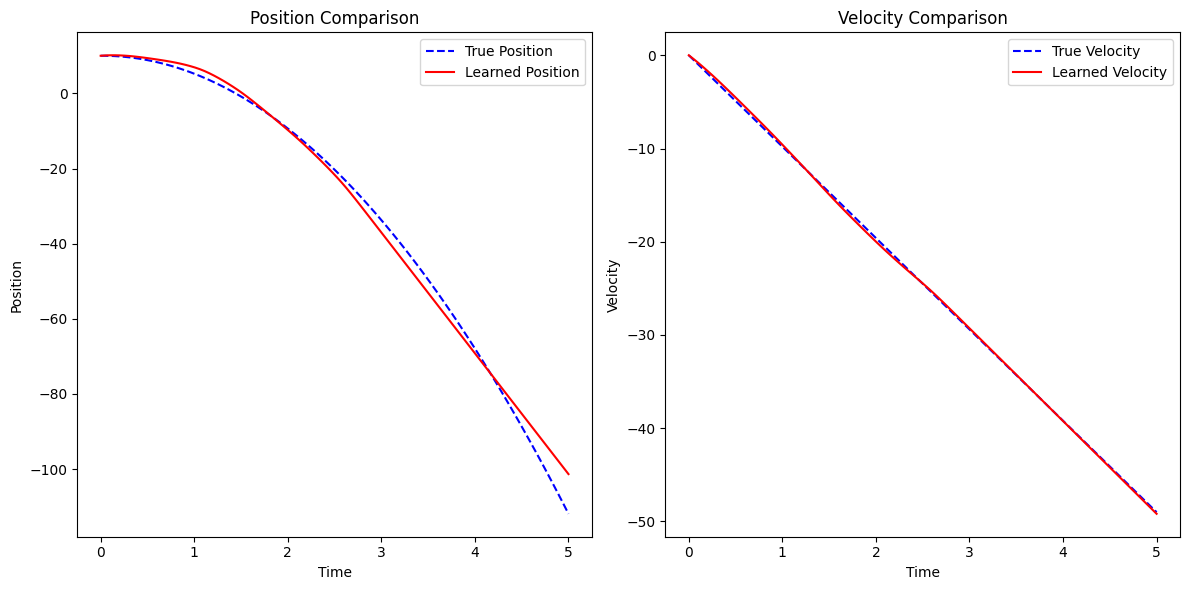

In [34]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

### STEP 1: Simulate Bouncing Ball Dynamics ###
class BouncingBallODE(nn.Module):
    def __init__(self, gravity=9.8):
        super().__init__()
        self.gravity = gravity  # Fixed gravity

    def forward(self, t, state):
        """
        Defines the physics of a bouncing ball: dpos/dt = vel, dvel/dt = -gravity.
        """
        if not isinstance(state, tuple) or len(state) != 2:
            raise TypeError("Expected state to be a tuple (pos, vel), but got a different type.")

        pos, vel = state  # Ensure state is a tuple
        dpos = vel
        dvel = -self.gravity * torch.ones_like(vel)
        return (dpos, dvel)  # Return as a tuple

    def state_update(self, state):
        """
        Updates the velocity after a bounce by flipping its sign.
        """
        pos, vel = state
        pos = pos + 1e-4  # Avoid triggering event immediately
        vel = -vel * 0.8  # Apply coefficient of restitution
        return (pos, vel)

    def simulate(self, t, y0):
        """
        Simulates the bouncing ball trajectory using ode_solve().
        """
        if not isinstance(y0, torch.Tensor) or y0.shape[0] != 2:
            raise TypeError("y0 should be a tensor with two elements (pos, vel).")

        y0 = (y0[0], y0[1])  # Ensure it is passed as a tuple

        solution = [y0]  # Store full trajectory
        for i in range(len(t) - 1):
            next_state = ode_solve(solution[-1], t[i], t[i+1], self.forward)
            solution.append(next_state)

        # Convert tuple states back to tensor
        pos_traj = torch.stack([s[0] for s in solution])
        vel_traj = torch.stack([s[1] for s in solution])
        return torch.stack((pos_traj, vel_traj), dim=-1)  # Shape: (timesteps, 2)


### STEP 2: Custom Euler ODE Solver ###
def ode_solve(z0, t0, t1, f):
    """
    Euler ODE initial value solver.
    """
    h_max = 0.05  # Maximum step size
    n_steps = math.ceil((abs(t1 - t0) / h_max).max().item())
    h = (t1 - t0) / n_steps
    t = t0

    if not isinstance(z0, tuple):
        raise TypeError("Expected z0 to be a tuple (pos, vel), but got a tensor.")

    z = z0  # Ensure z is a tuple

    for _ in range(n_steps):
        dzdt = f(t, z)  # Should return a tuple (dpos, dvel)
        if not isinstance(dzdt, tuple):
            raise TypeError("Expected f() to return a tuple (dpos, dvel), but got a tensor.")

        # Euler step for tuples
        z = tuple(zi + h * dzi for zi, dzi in zip(z, dzdt))
        t = t + h

    return z


### STEP 3: Define Neural ODE Model ###
class ODEFunc(nn.Module):
    def __init__(self):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 2)
        )

    def forward(self, t, z):
        # Combine position and velocity into a single tensor
        z_tensor = torch.stack(z, dim=-1) if isinstance(z, tuple) else z
        # Neural network processes the combined state
        dz = self.net(z_tensor)
        # Split the output back into position and velocity
        return (dz[0], dz[1])

class NeuralODE(nn.Module):
    def __init__(self, func):
        super(NeuralODE, self).__init__()
        self.func = func

    def forward(self, z0, t):
        """
        Solves ODE using the custom Euler solver.
        Generates a full trajectory starting from the initial state.
        """
        # If z0 is a tensor, convert to tuple
        if isinstance(z0, torch.Tensor):
            if z0.dim() == 1:
                z0 = z0.unsqueeze(0)  # Add batch dimension if not present
            
            if z0.dim() == 2 and z0.shape[1] == 2:
                z_tuple = (z0[0, 0], z0[0, 1])  # Convert to tuple of (pos, vel)
            else:
                raise TypeError(f"Expected z0 to have shape (batch_size, 2), but got {z0.shape}")
        else:
            z_tuple = z0

        # Generate full trajectory
        trajectory = [z_tuple]
        for i in range(len(t) - 1):
            next_state = ode_solve(trajectory[-1], t[i], t[i + 1], self.func)
            trajectory.append(next_state)

        # Convert trajectory to tensor
        pos_traj = torch.stack([state[0] for state in trajectory])
        vel_traj = torch.stack([state[1] for state in trajectory])
        return torch.stack((pos_traj, vel_traj), dim=-1)  # Shape: (timesteps, 2)


### STEP 4: Generate Training Data ###
def generate_data():
    t = torch.linspace(0, 5, 100)
    y0 = torch.tensor([10.0, 0.0])  # Initial position and velocity
    bouncing_ball = BouncingBallODE()
    true_trajectory = bouncing_ball.simulate(t, y0)
    
    return t, true_trajectory


### STEP 5: Train the Neural ODE ###
def train_neural_ode():
    t, true_trajectory = generate_data()
    neural_ode = NeuralODE(ODEFunc())
    optimizer = torch.optim.Adam(neural_ode.parameters(), lr=0.001)  # Reduced learning rate
    loss_fn = nn.MSELoss()

    num_epochs = 2000
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        # Use initial state as input
        initial_state = true_trajectory[0, :]  # Initial state is the first timestep
        pred_trajectory = neural_ode(initial_state, t)
        
        # Compute loss for both position and velocity
        loss = loss_fn(pred_trajectory, true_trajectory)
        loss.backward()
        optimizer.step()

        if epoch % 200 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")

    return neural_ode, t, true_trajectory


### STEP 6: Compare True vs Learned Dynamics ###
def plot_results(neural_ode, t, true_trajectory):
    with torch.no_grad():
        initial_state = true_trajectory[0, :]
        learned_trajectory = neural_ode(initial_state, t)

    plt.figure(figsize=(12, 6))
    
    # Position subplot
    plt.subplot(1, 2, 1)
    plt.plot(t.numpy(), true_trajectory[:, 0].numpy(), label="True Position", color="blue", linestyle="dashed")
    plt.plot(t.numpy(), learned_trajectory[:, 0].numpy(), label="Learned Position", color="red")
    plt.xlabel("Time")
    plt.ylabel("Position")
    plt.title("Position Comparison")
    plt.legend()

    # Velocity subplot
    plt.subplot(1, 2, 2)
    plt.plot(t.numpy(), true_trajectory[:, 1].numpy(), label="True Velocity", color="blue", linestyle="dashed")
    plt.plot(t.numpy(), learned_trajectory[:, 1].numpy(), label="Learned Velocity", color="red")
    plt.xlabel("Time")
    plt.ylabel("Velocity")
    plt.title("Velocity Comparison")
    plt.legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    neural_ode, t, true_trajectory = train_neural_ode()
    plot_results(neural_ode, t, true_trajectory)

Epoch 50, Loss: 38.425782192560554


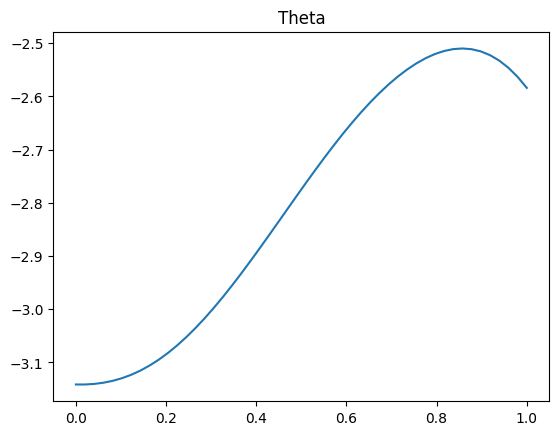

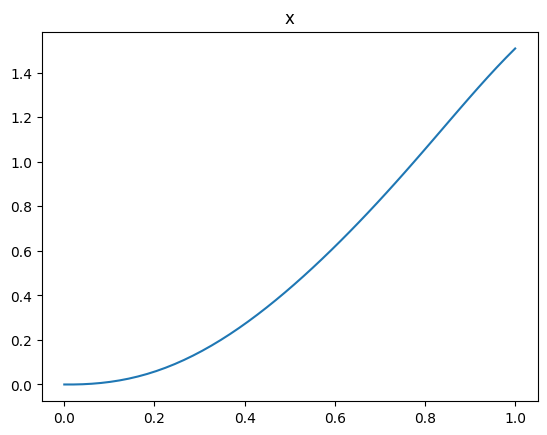

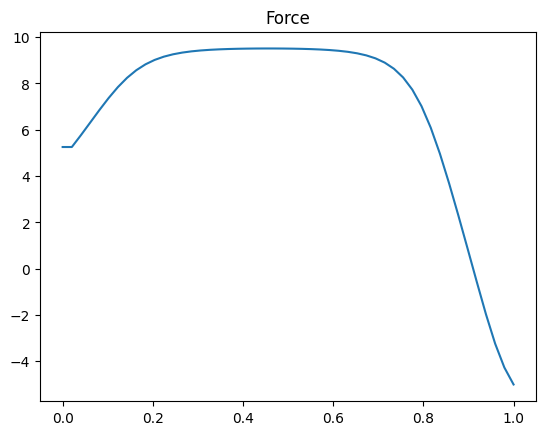

Epoch 100, Loss: 19.856620486128083


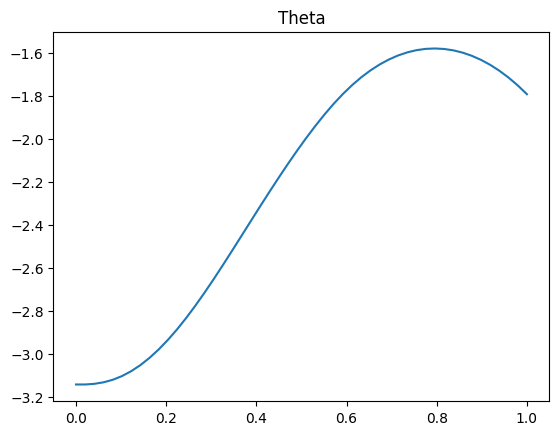

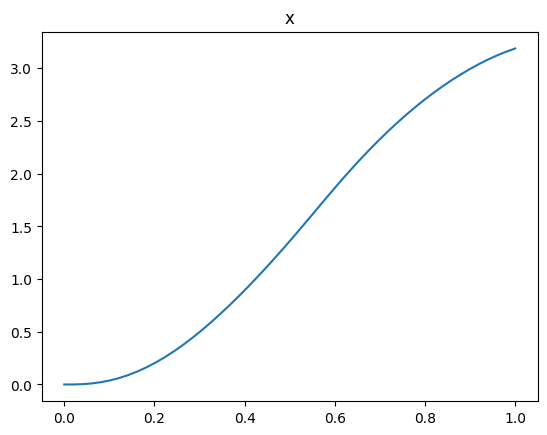

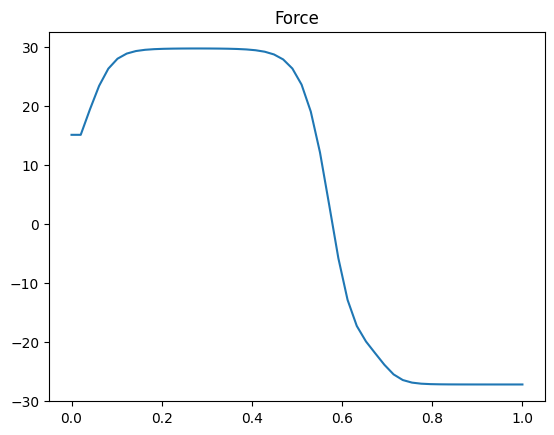

Epoch 150, Loss: 3.5340388473920976


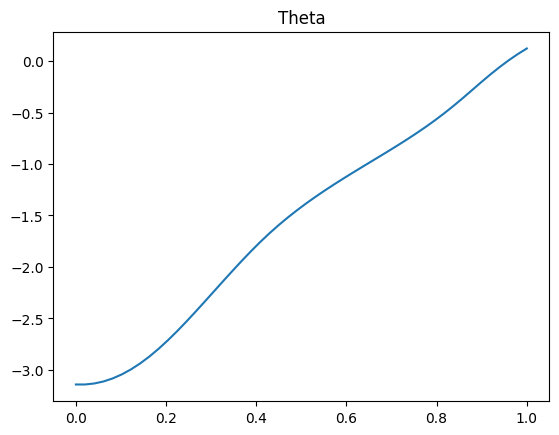

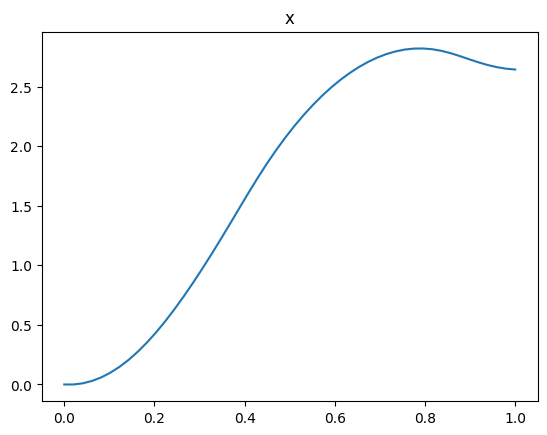

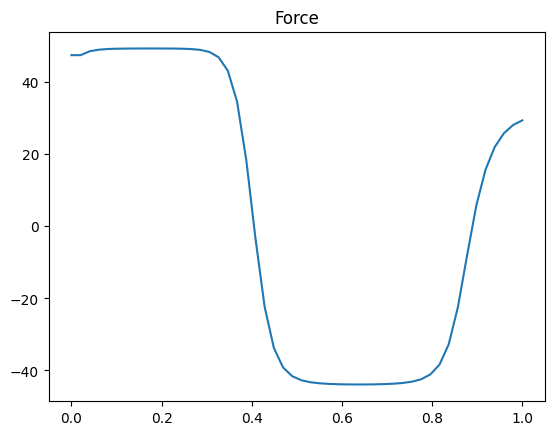

Epoch 200, Loss: 3.4891586924816713


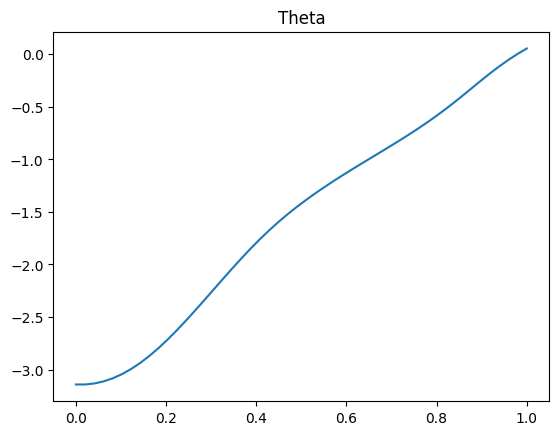

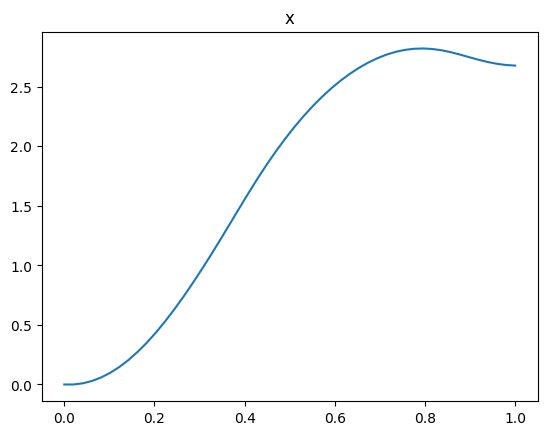

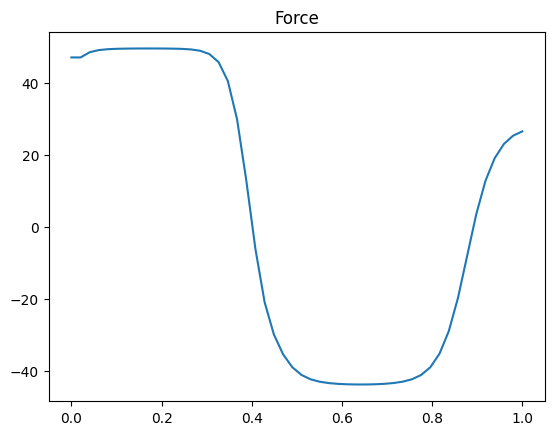

Epoch 250, Loss: 3.468048613375568


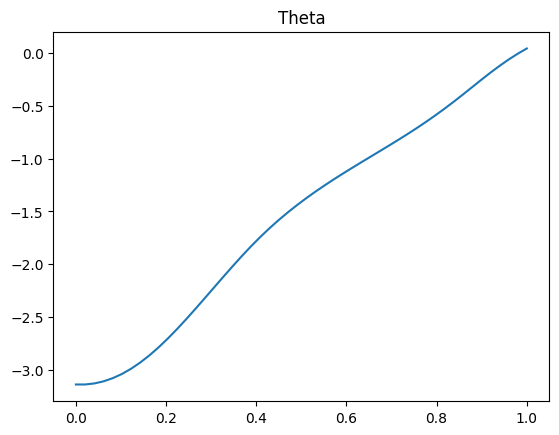

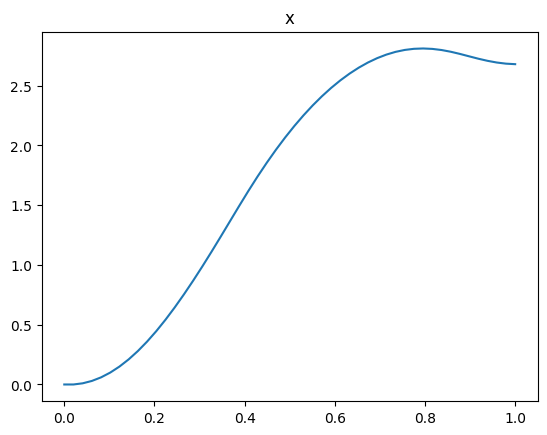

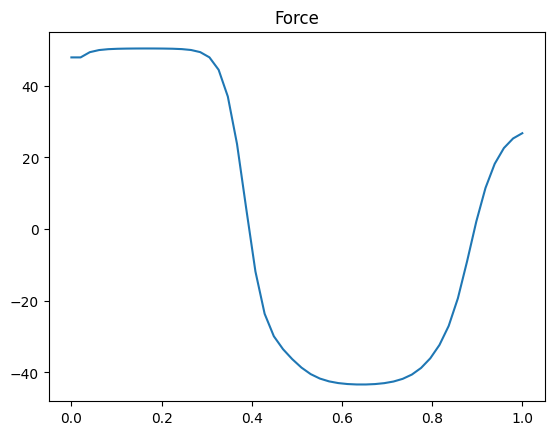

Epoch 300, Loss: 3.4414517172605876


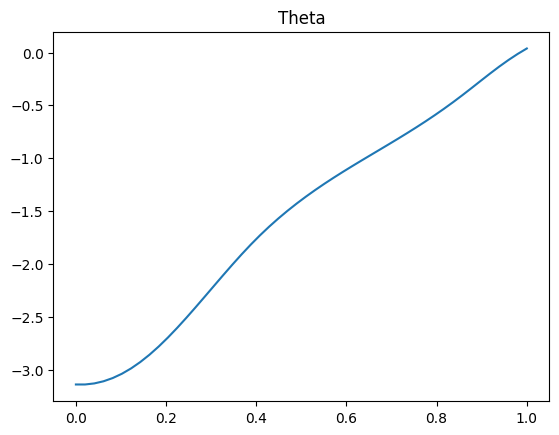

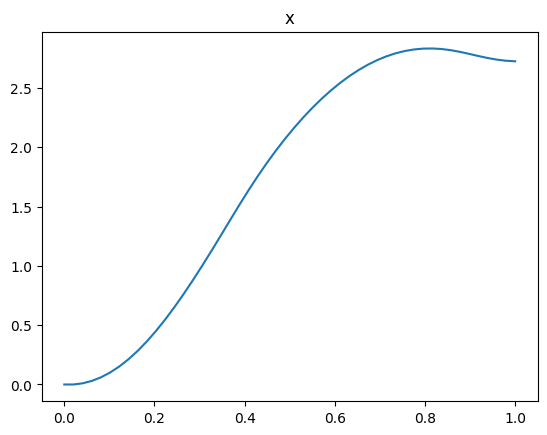

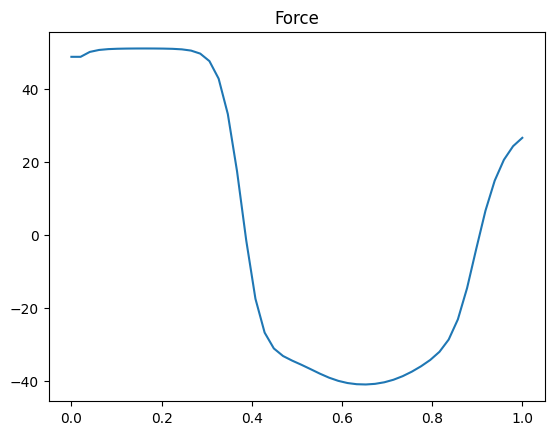

Epoch 350, Loss: 3.5813914665004085


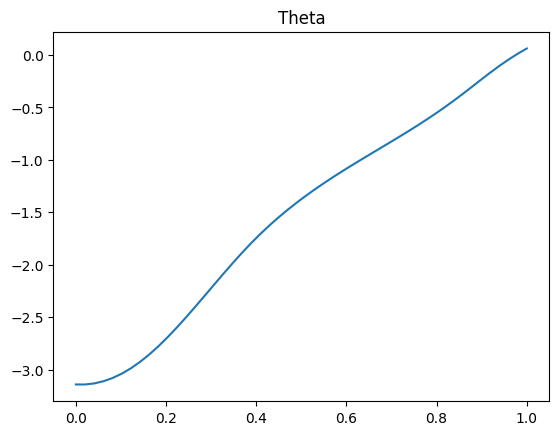

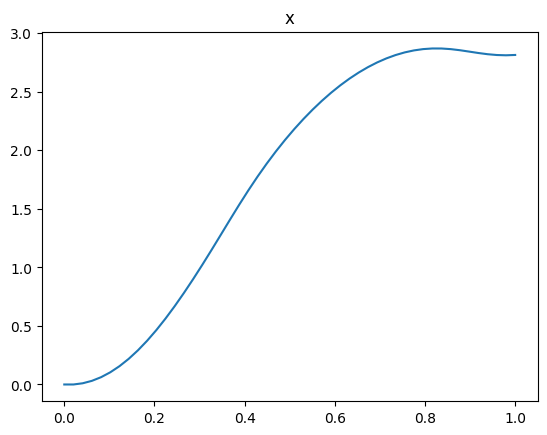

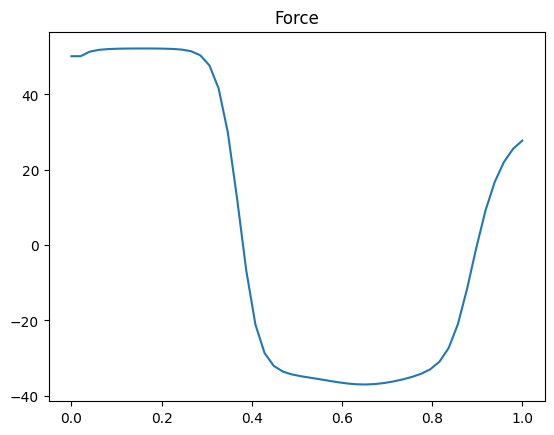

Epoch 400, Loss: 3.393688215618732


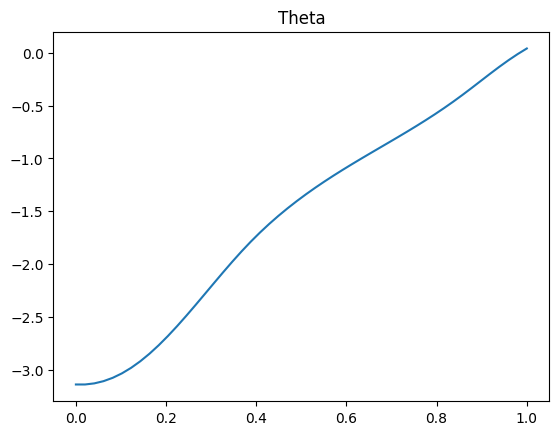

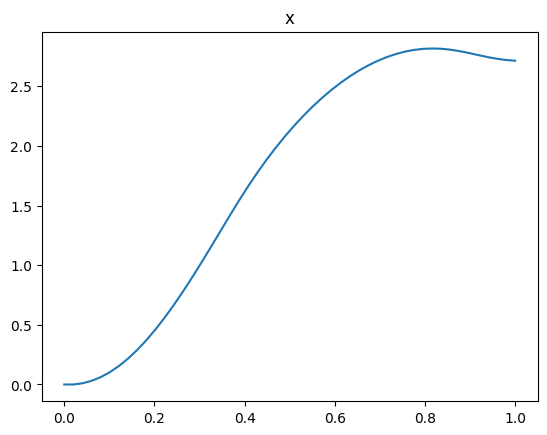

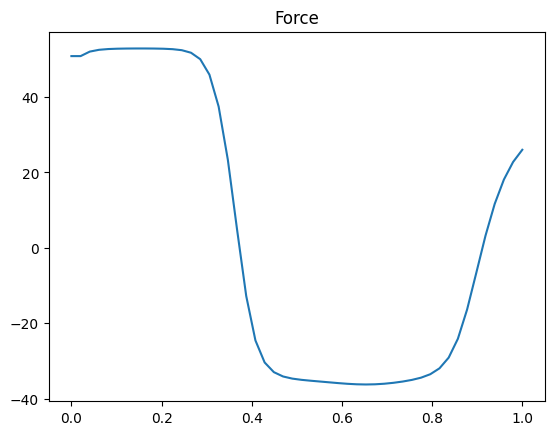

Epoch 450, Loss: 3.3706993875050637


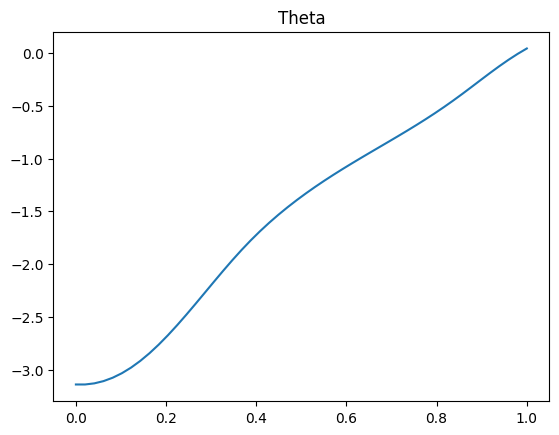

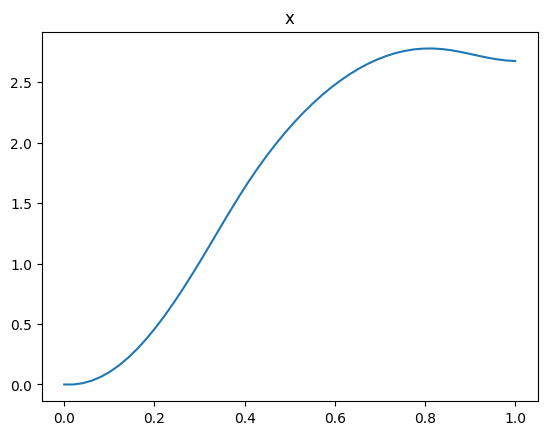

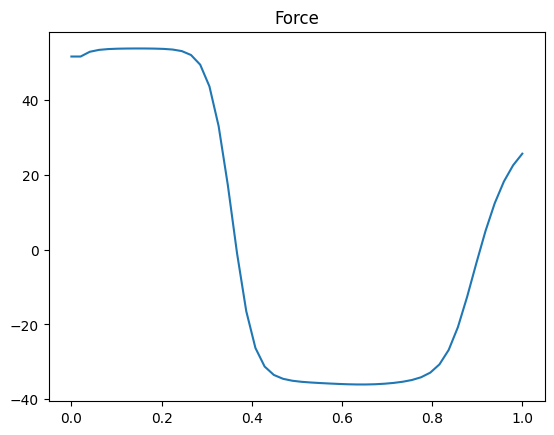

Epoch 500, Loss: 3.355111511031055


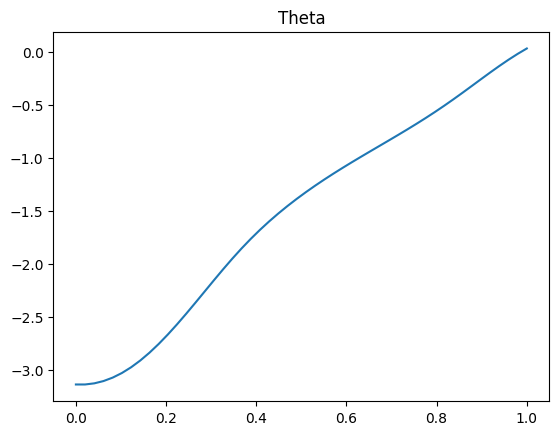

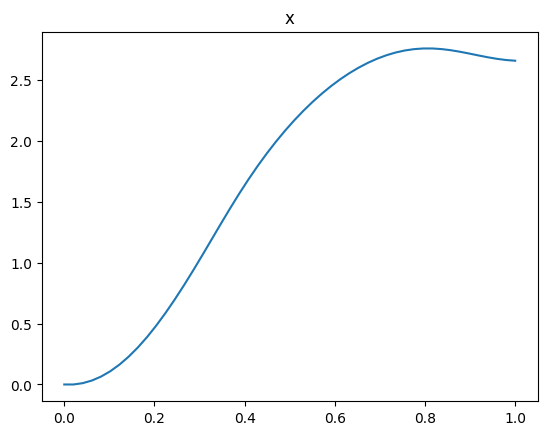

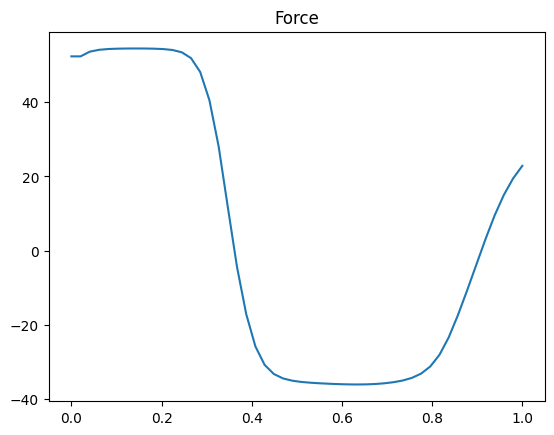

Epoch 550, Loss: 3.3271355560743254


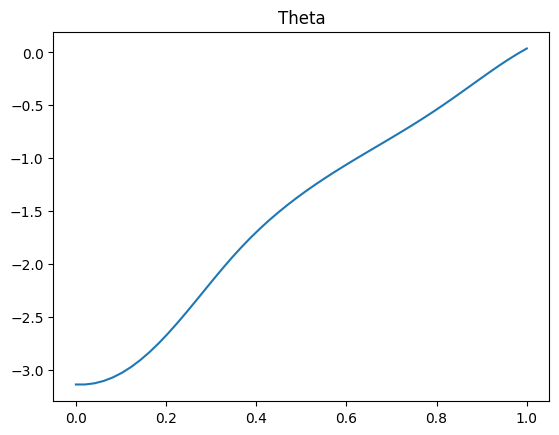

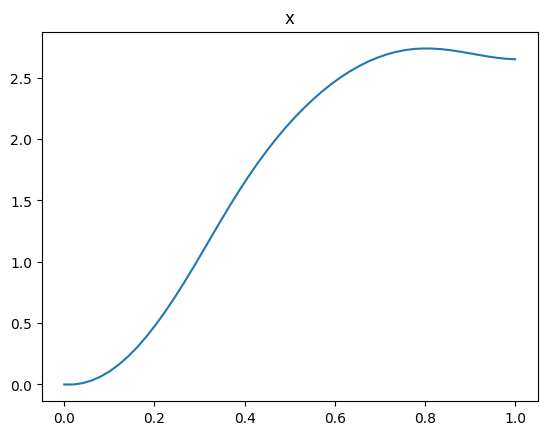

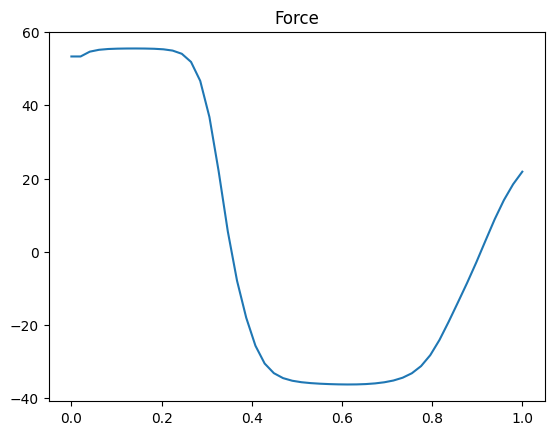

Epoch 600, Loss: 3.301433613477977


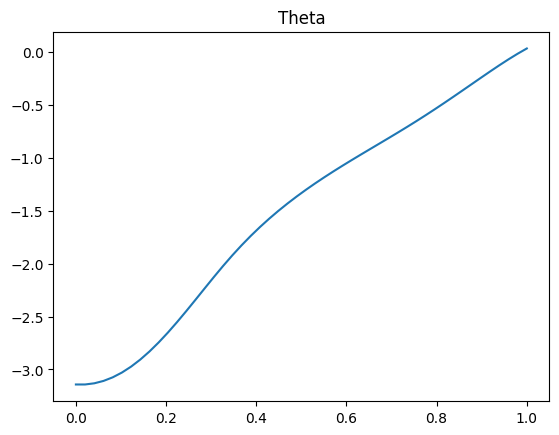

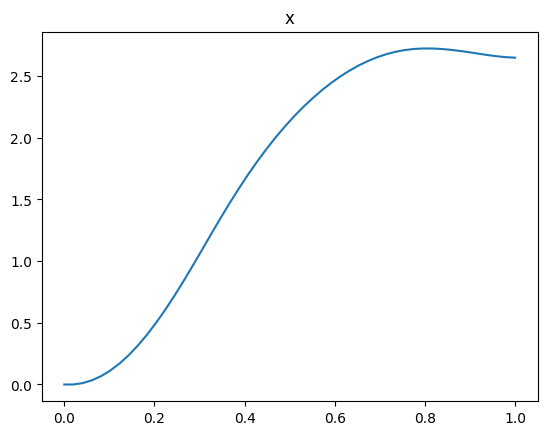

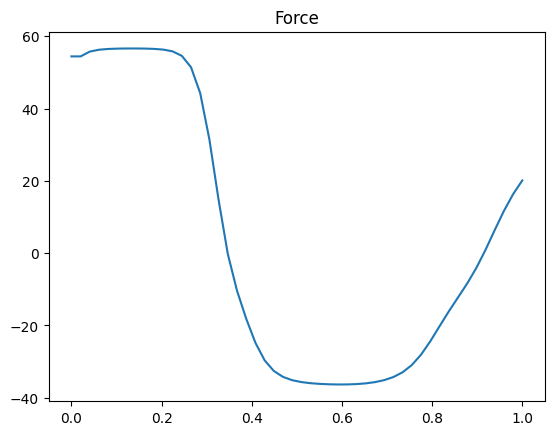

Epoch 650, Loss: 3.275775163790541


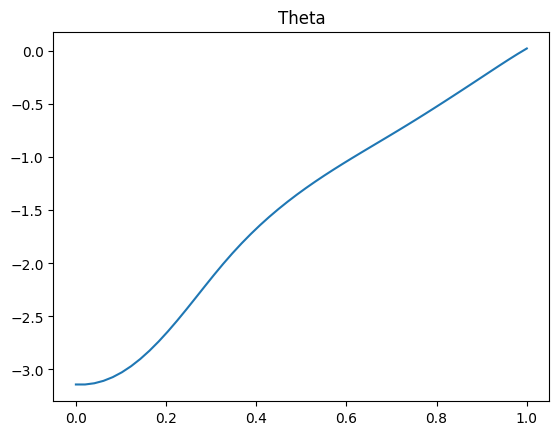

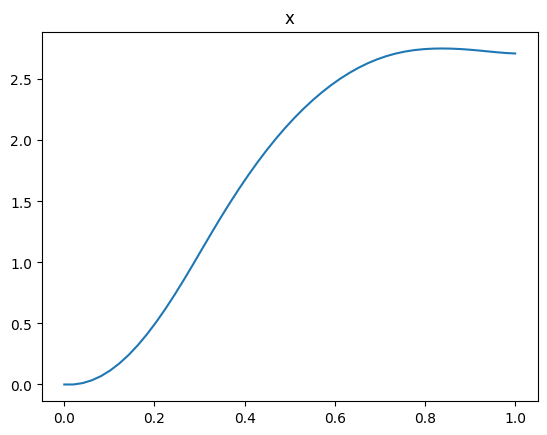

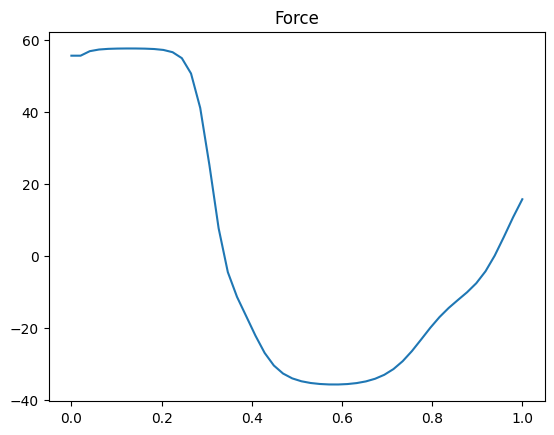

Epoch 700, Loss: 3.2437654345907267


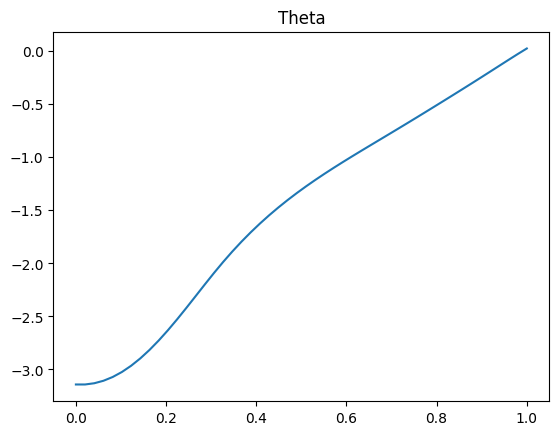

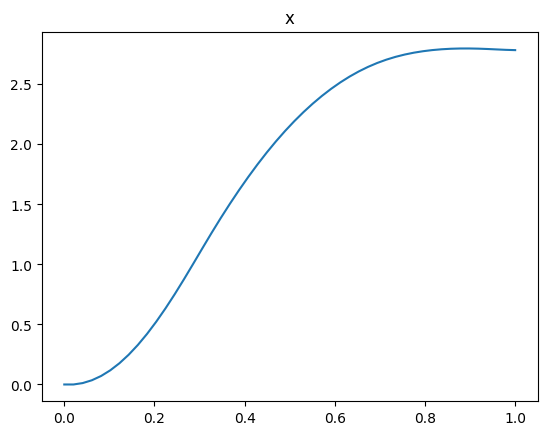

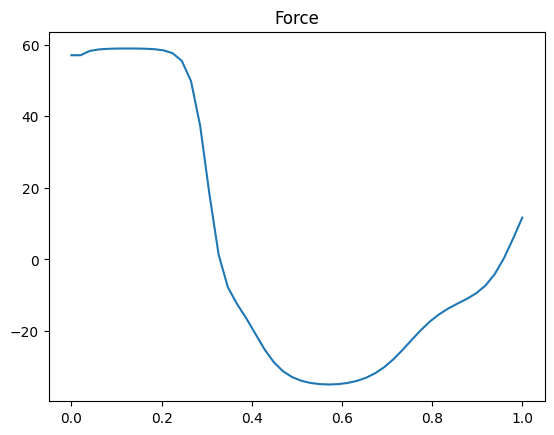

Epoch 750, Loss: 3.2132891667535994


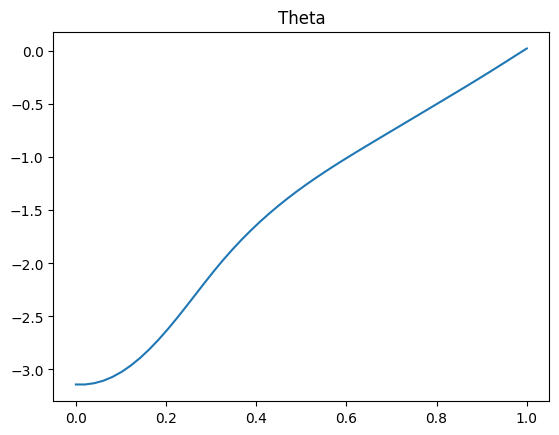

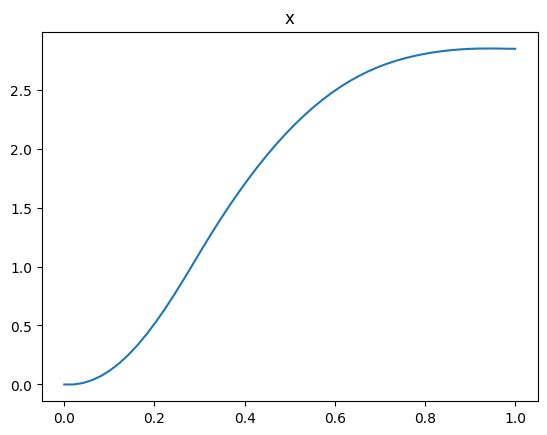

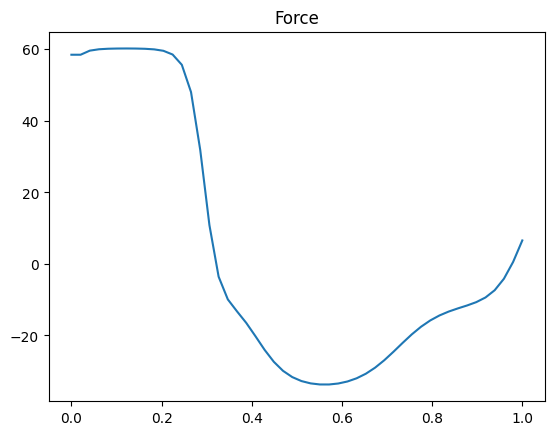

Epoch 800, Loss: 3.1838258628870517


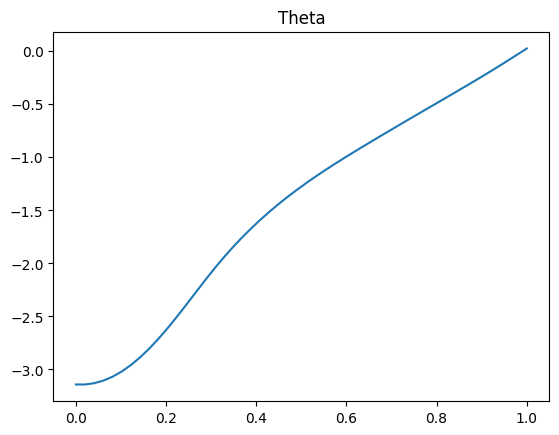

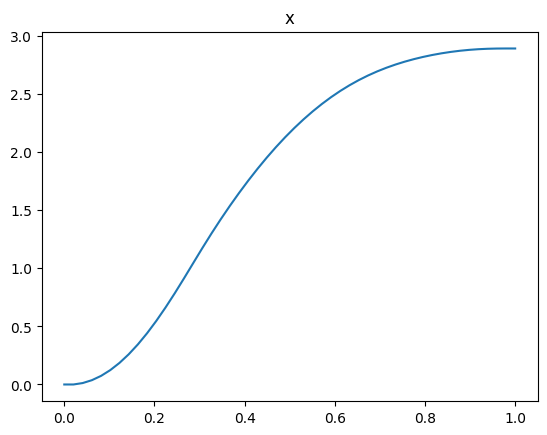

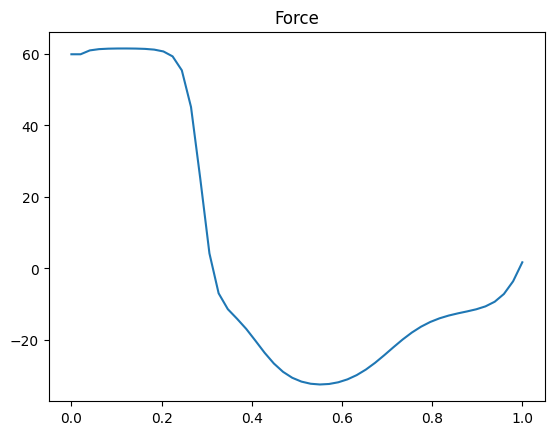

Epoch 850, Loss: 3.155932220777146


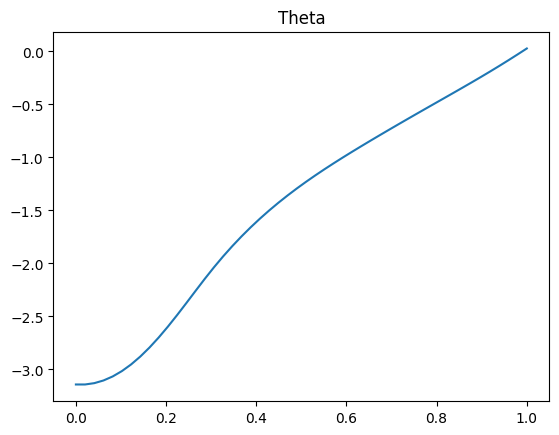

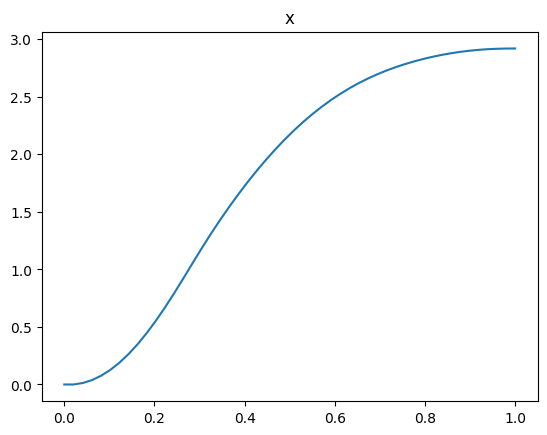

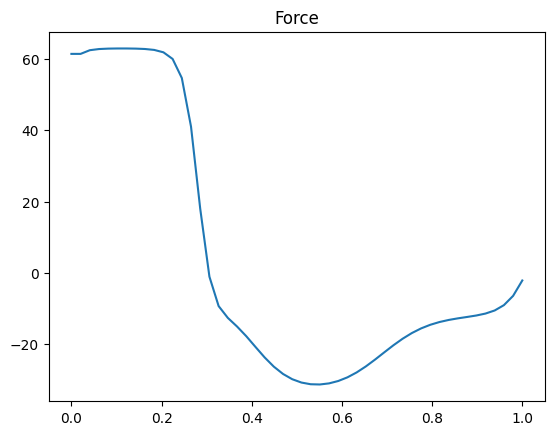

Epoch 900, Loss: 3.129438977837008


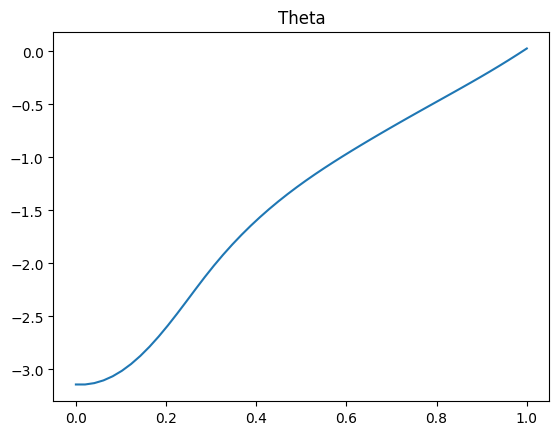

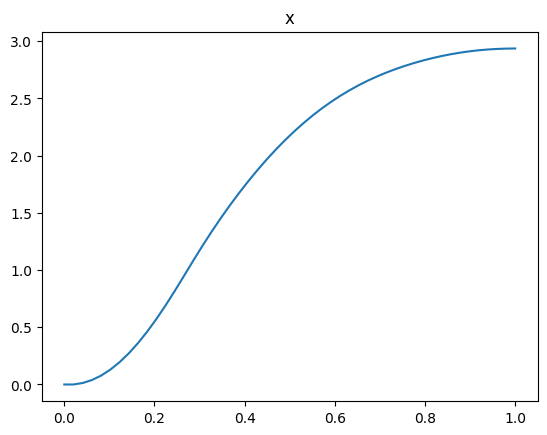

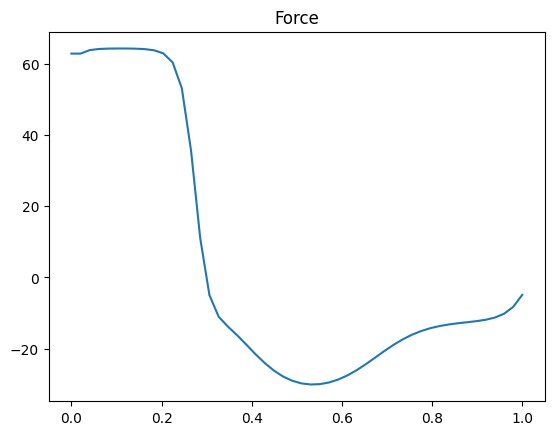

Epoch 950, Loss: 3.1039576896307493


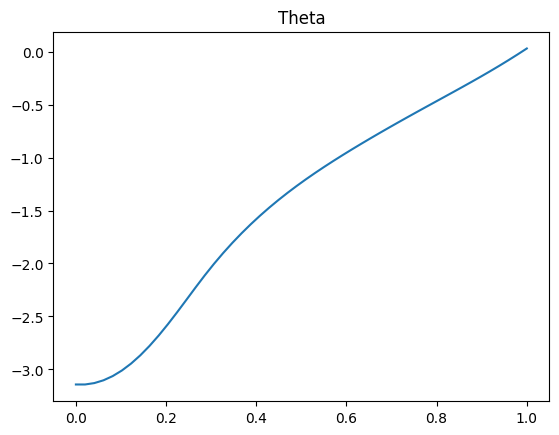

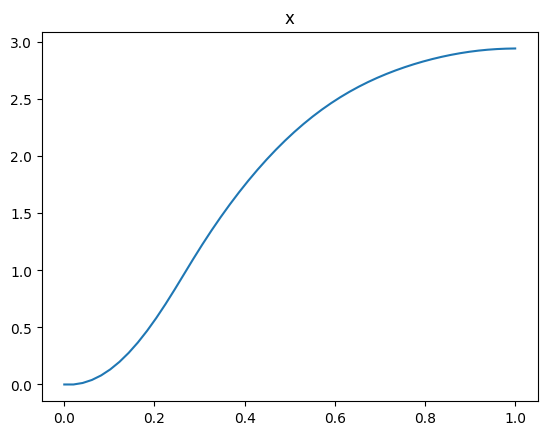

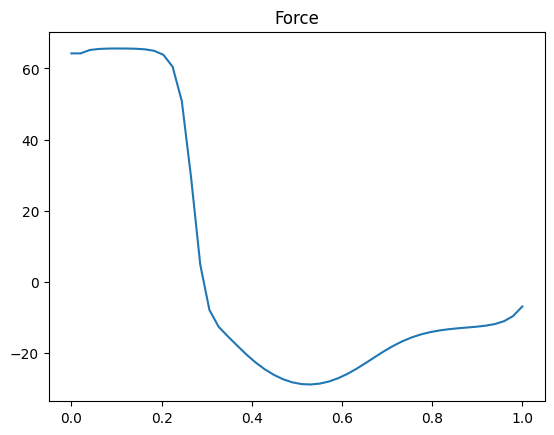

Epoch 1000, Loss: 3.079157010081476


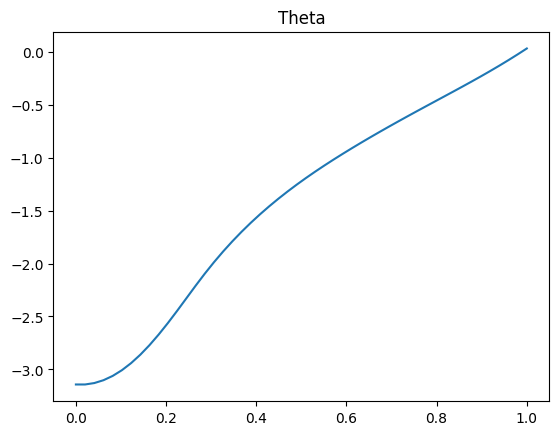

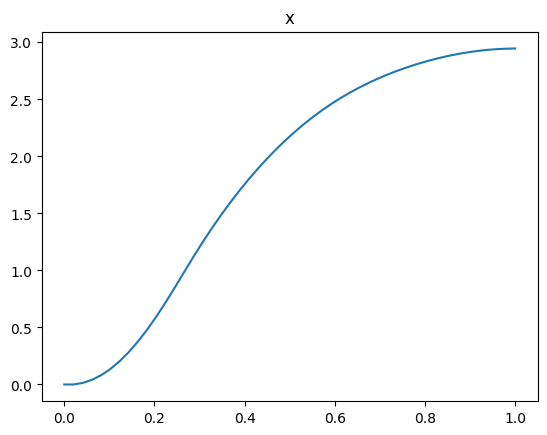

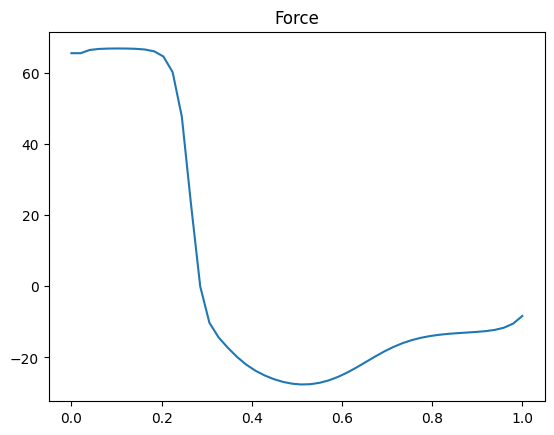

Epoch 1050, Loss: 3.054967557368262


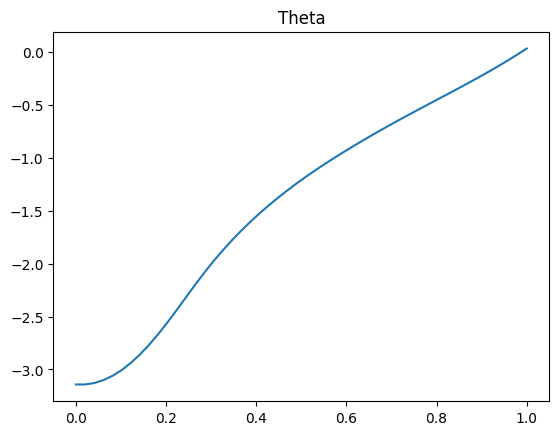

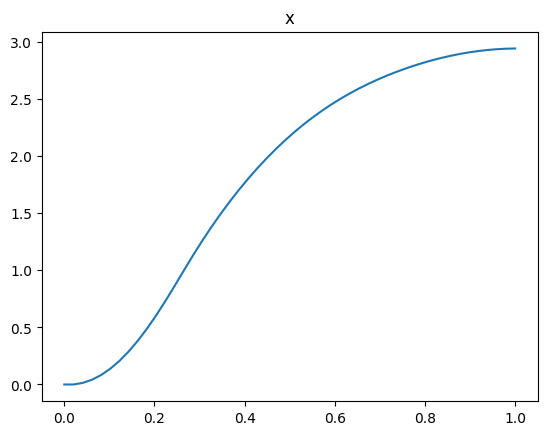

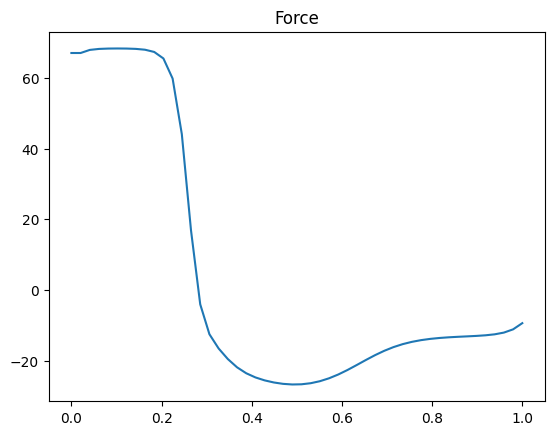

Epoch 1100, Loss: 3.0314929422216794


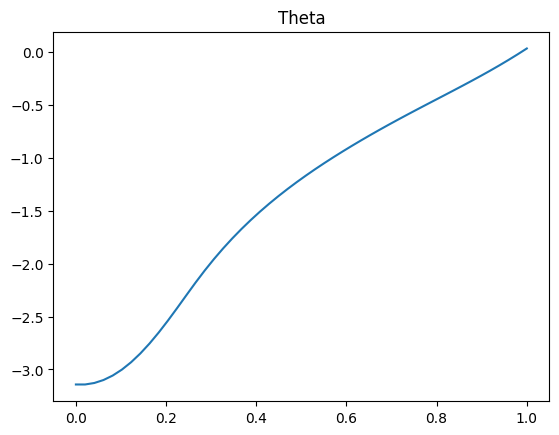

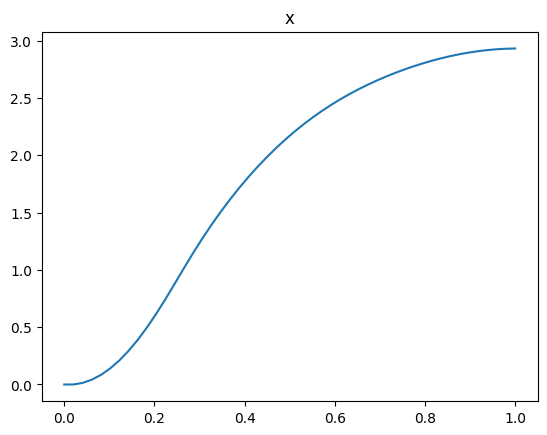

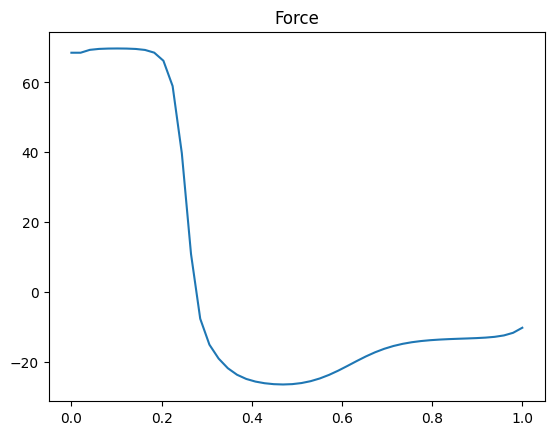

Epoch 1150, Loss: 3.008782598873593


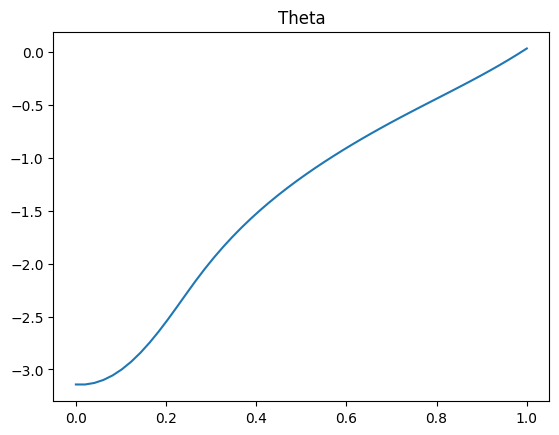

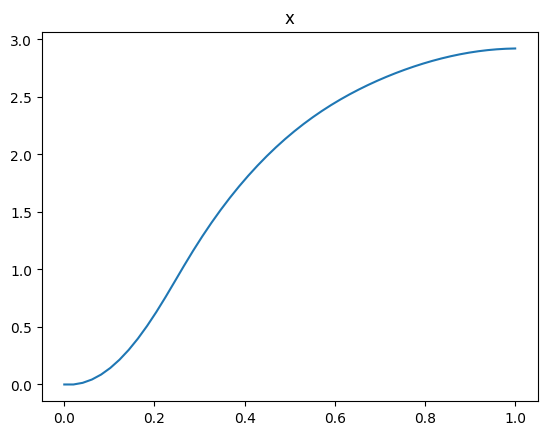

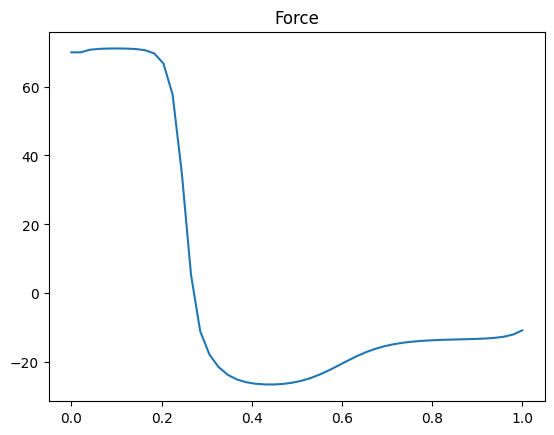

Epoch 1200, Loss: 2.986857801776079


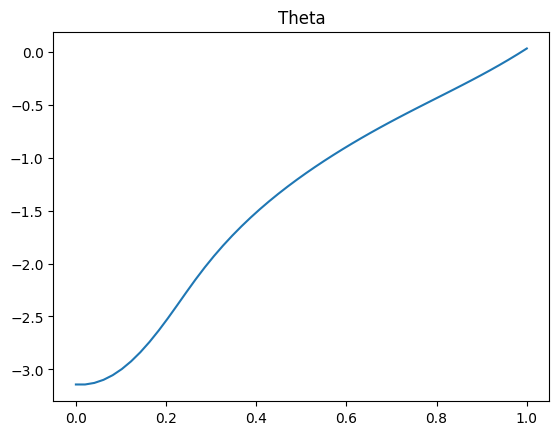

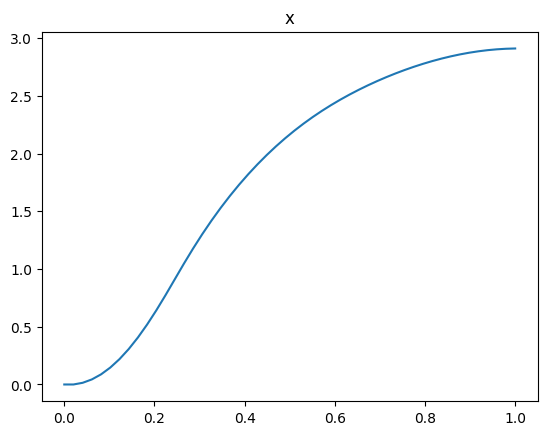

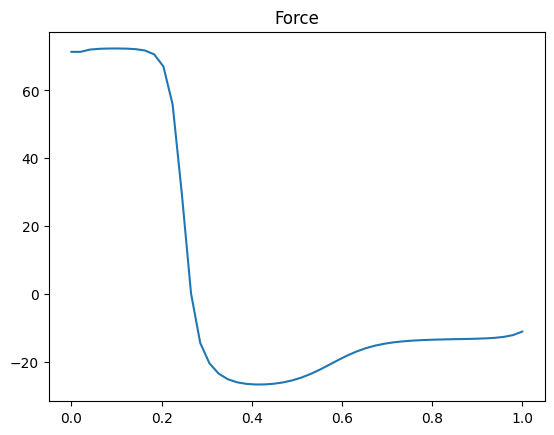

Epoch 1250, Loss: 2.9657753322355176


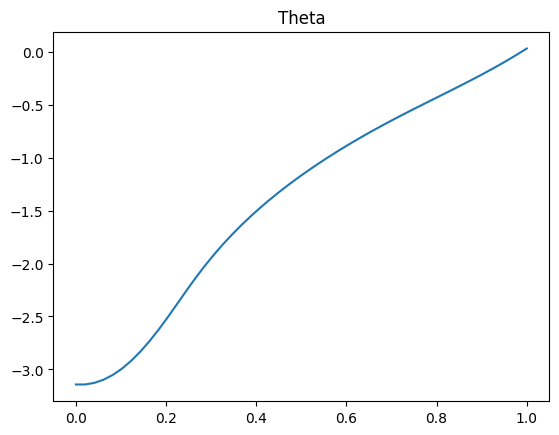

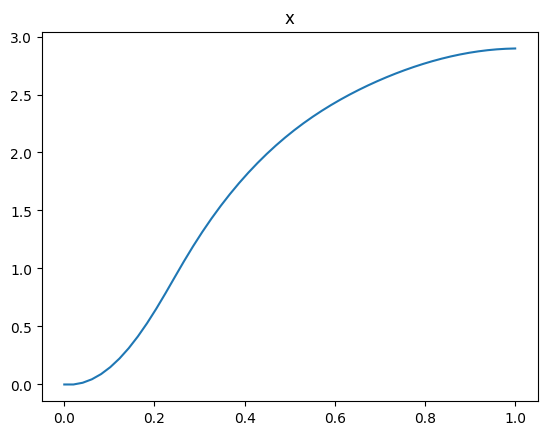

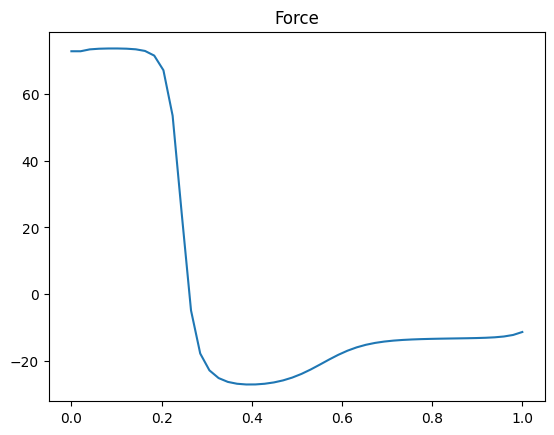

Epoch 1300, Loss: 2.9455970311925324


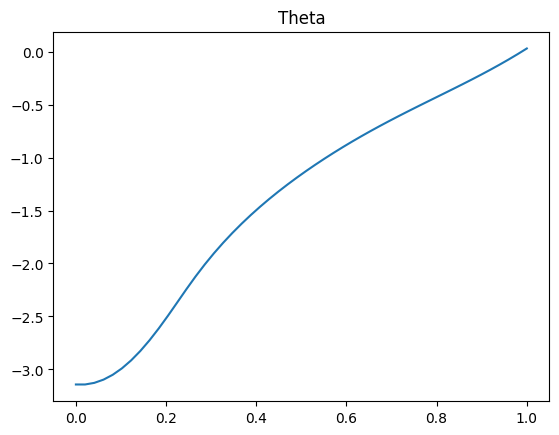

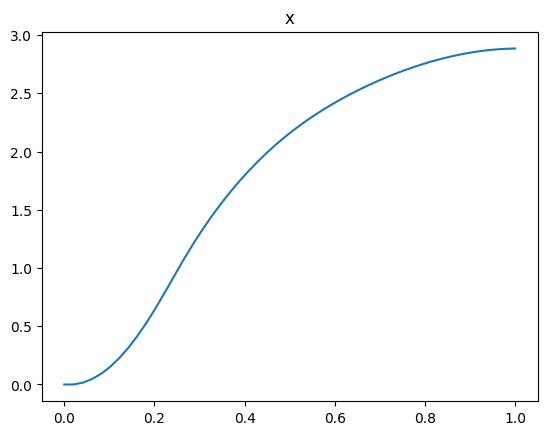

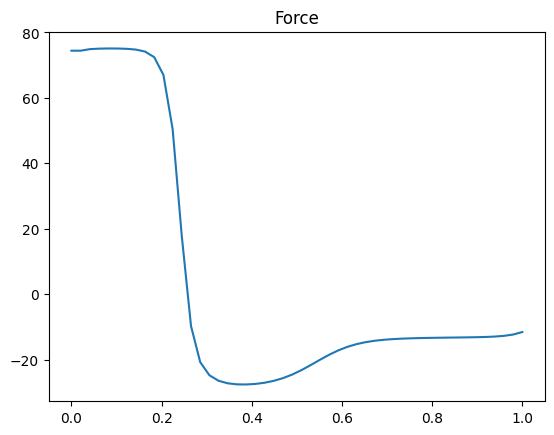

Epoch 1350, Loss: 2.92631851923121


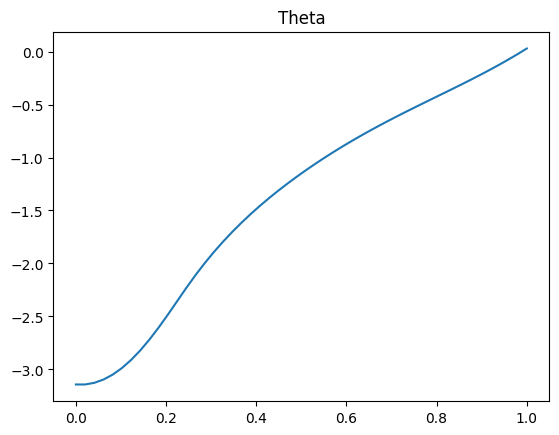

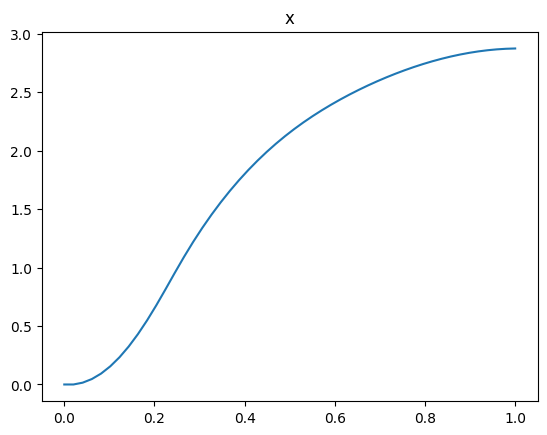

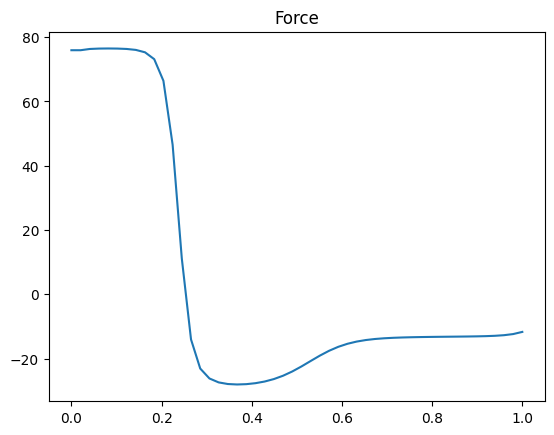

Epoch 1400, Loss: 2.9078628737101333


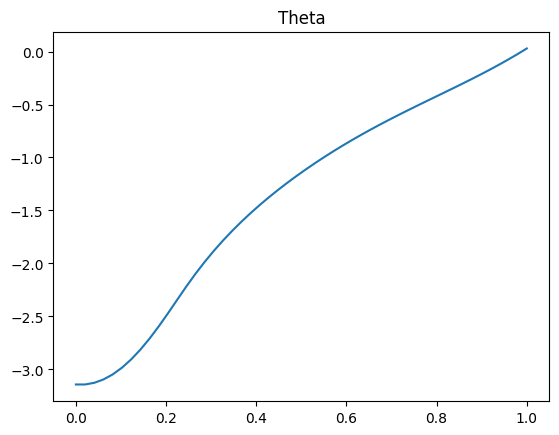

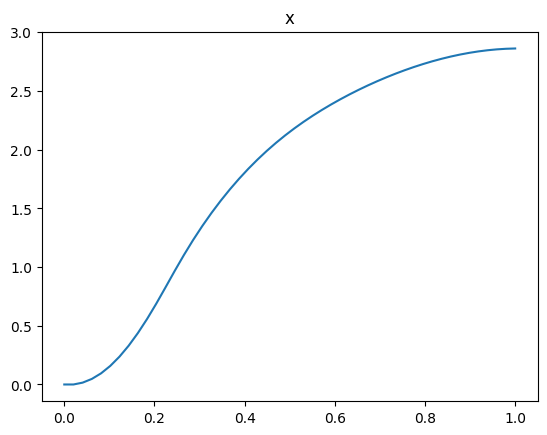

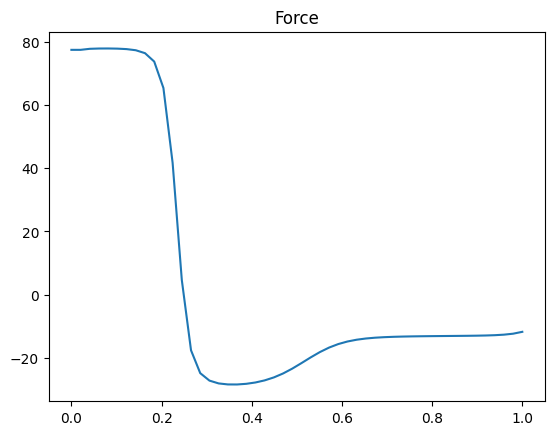

Epoch 1450, Loss: 2.8901286847508554


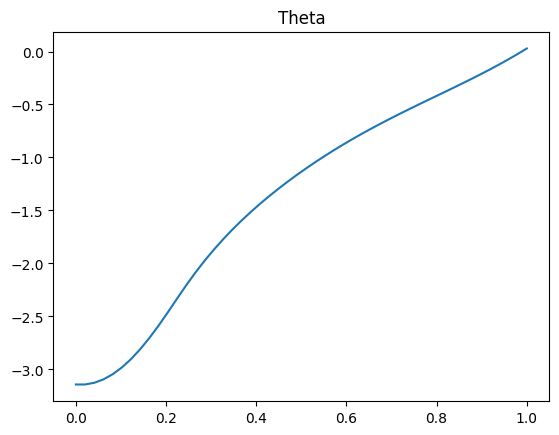

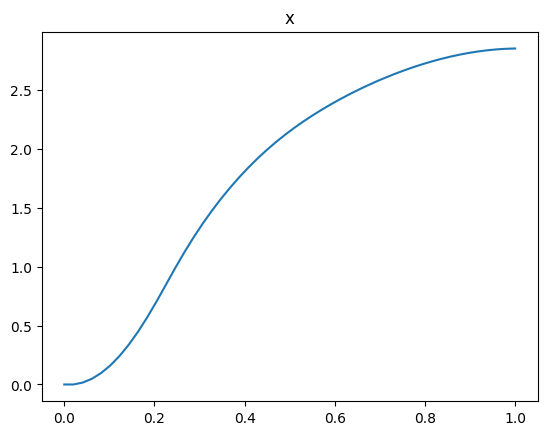

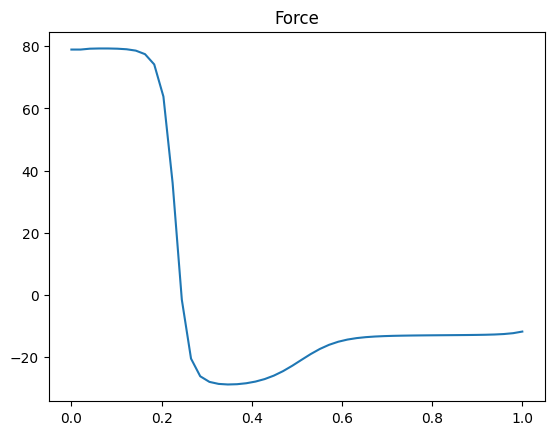

Epoch 1500, Loss: 2.873022636435645


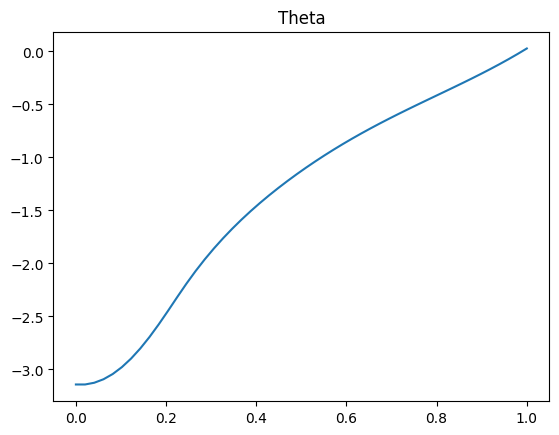

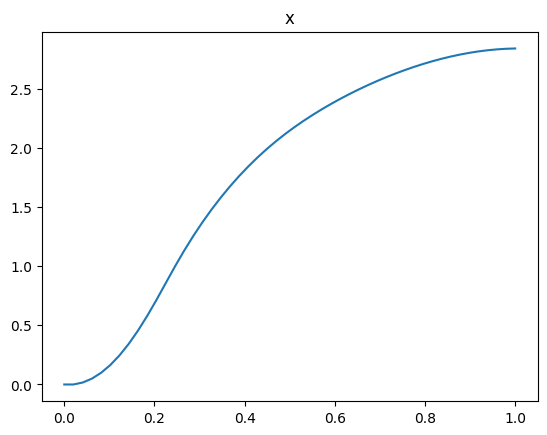

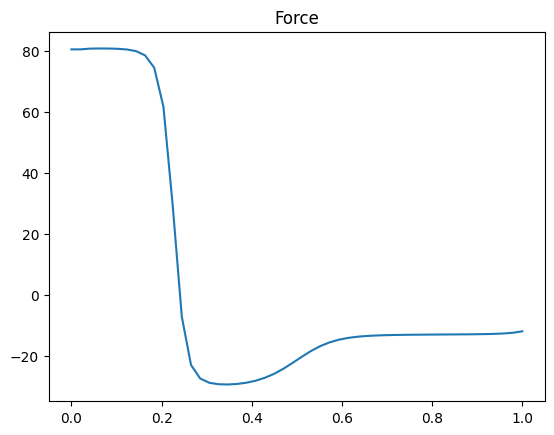

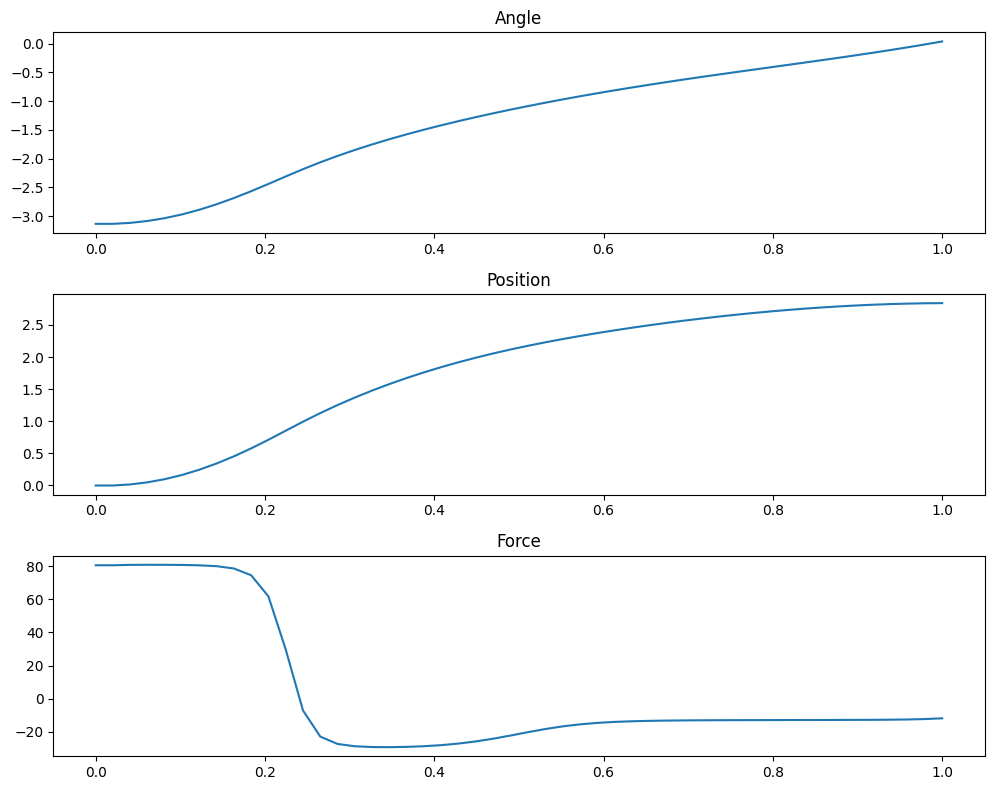

MovieWriter imagemagick unavailable; using Pillow instead.


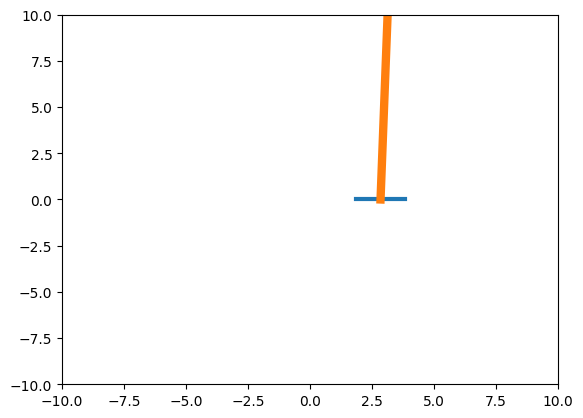

In [46]:
"""
Neural ODE for Reinforcement Learning and Nonlinear Optimal Control:
Cartpole Problem Revisited

This is a Python translation of the following Julia code:
  https://medium.com/@paulshen_62280/neural-ode-for-reinforcement-learning-and-nonlinear-optimal-control-cartpole-problem-revisited-5408018b8d71

Paul Shen
pxshen@alumni.stanford.edu

This script uses only NumPy, PyTorch, Matplotlib, and JSON.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import json

# Set PyTorch’s default floating point type (double precision)
torch.set_default_dtype(torch.float64)

### --- Physical parameters --- ###
m = 1.0   # pole mass [kg]
M = 2.0   # cart mass [kg]
L = 1.0   # pole length [m]
g = 9.8   # gravitational acceleration [m/s^2]

### --- Utility: Map angle to [-pi, pi) --- ###
def modpi(theta):
    # Works for torch tensors as well.
    return torch.remainder(theta + np.pi, 2 * np.pi) - np.pi

### --- System dynamics (without control) --- ###
def cartpole_torch(u, t, p_func):
    """
    Computes the time derivative of the state for the cartpole system.
    
    Parameters:
      u: torch tensor of shape (4,) representing [x, dx, theta, dtheta]
      t: time (float)
      p_func: a function of time that returns the lateral force (a torch scalar)
      
    Returns:
      torch tensor of shape (4,) containing the derivatives.
    """
    x, dx, theta, dtheta = u[0], u[1], u[2], u[3]
    force = p_func(t)
    du1 = dx
    du2 = (force + m * torch.sin(theta) * (L * dtheta**2 - g * torch.cos(theta))) / (M + m * torch.sin(theta)**2)
    du3 = dtheta
    du4 = (-force * torch.cos(theta) - m * L * dtheta**2 * torch.sin(theta) * torch.cos(theta) +
           (M + m) * g * torch.sin(theta)) / (L * (M + m * torch.sin(theta)**2))
    return torch.stack([du1, du2, du3, du4])

### --- Neural network controller --- ###
# The network takes as input [cos(theta), sin(theta), theta_dot] and outputs the cart force.
class Controller(nn.Module):
    def __init__(self):
        super(Controller, self).__init__()
        self.fc1 = nn.Linear(3, 8)
        self.fc2 = nn.Linear(8, 1)
        
    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the controller. Its parameters (weights) will be learned.
controller = Controller()

### --- Controlled system dynamics --- ###
def cartpole_controlled_torch(u, t):
    """
    Computes the derivative of the full state (cartpole state plus impulse) when the controller is active.
    
    State u is a torch tensor of shape (5,):
      u[0:4] = [x, dx, theta, dtheta]
      u[4]   = impulse (integral of force)
    
    The controller is applied to [cos(theta), sin(theta), dtheta] to determine the force.
    """
    theta = u[2]
    dtheta = u[3]
    # Form the network input vector.
    inp = torch.stack([torch.cos(theta), torch.sin(theta), dtheta])
    # The network returns a (1,)-shaped tensor; squeeze to get a scalar.
    force = controller(inp).squeeze()
    # Compute the derivatives of the cartpole state using the provided force.
    du_cartpole = cartpole_torch(u[:4], t, lambda t: force)
    # The fifth derivative is just the force (the time derivative of the impulse).
    du_full = torch.cat([du_cartpole, force.unsqueeze(0)])
    return du_full

### --- Simple Euler ODE solver (differentiable) --- ###
def euler_integration(u0, tsteps, func):
    """
    Performs Euler integration of the ODE u_dot = f(u,t) given an initial state u0.
    
    Parameters:
      u0: initial state (torch tensor)
      tsteps: 1D torch tensor of time points
      func: function f(u, t) that returns the state derivative
    
    Returns:
      Tensor of shape (len(tsteps), state_dim) representing the trajectory.
    """
    u = u0
    trajectory = [u0]
    t_list = tsteps.tolist()
    for i in range(len(t_list) - 1):
        t_current = t_list[i]
        t_next = t_list[i+1]
        dt_local = t_next - t_current
        u_dot = func(u, t_current)
        u = u + dt_local * u_dot
        trajectory.append(u)
    return torch.stack(trajectory, dim=0)

### --- Setup initial condition and time discretization --- ###
# Initial state: [x, dx, theta, dtheta, impulse]
u0 = torch.tensor([0.0, 0.0, np.pi, 0.0, 0.0])
t0, t1 = 0.0, 1.0
N = 50
tsteps = torch.linspace(t0, t1, N)
dt = (t1 - t0) / N

def predict_neuralode():
    """
    Solves the controlled cartpole ODE with the current controller parameters.
    """
    traj = euler_integration(u0, tsteps, cartpole_controlled_torch)
    return traj

### --- Wrangle solver output --- ###
def format_trajectory(pred):
    """
    Given a trajectory tensor of shape (N, 5), extract:
      - x, dx, theta, dtheta (the first four components)
      - force computed as the (finite difference) derivative of the impulse (fifth component)
      
    Returns:
      Tuple of five torch tensors: (x, dx, theta, dtheta, force)
    """
    x = pred[:, 0]
    dx = pred[:, 1]
    theta = modpi(pred[:, 2])
    dtheta = pred[:, 3]
    impulse = pred[:, 4]
    # Use torch.roll to perform a circular shift.
    impulse_shift = torch.roll(impulse, 1)
    tmp = (impulse - impulse_shift) / dt
    # Replace the first element with the second one (to avoid wrap‐around artifact)
    tmp[0] = tmp[1]
    force = tmp
    return x, dx, theta, dtheta, force

### --- Loss function --- ###
def loss_neuralode():
    """
    Computes the loss as a function of the current controller parameters.
    
    Loss is defined as:
      loss = (sum(theta^2) / N) + 4*(theta_end^2) + (dx_end^2)
    where theta_end and dx_end are the angle and velocity at the final time.
    
    Returns:
      A tuple (loss, pred) where pred is the raw trajectory.
    """
    pred = predict_neuralode()
    x, dx, theta, dtheta, force = format_trajectory(pred)
    loss = torch.sum(theta**2) / N + 4 * theta[-1]**2 + dx[-1]**2
    return loss, pred

### --- Callback to monitor training progress --- ###
global_epoch = 0
data_record = None

def training_callback(loss_value, pred):
    """
    Called after each training epoch.
    Prints the loss and, every 50 epochs, plots theta, x and force.
    Also stores the latest trajectory data.
    """
    global global_epoch, data_record
    global_epoch += 1
    x_val, dx_val, theta_val, dtheta_val, force_val = format_trajectory(pred.detach())
    data_record = (x_val, dx_val, theta_val, dtheta_val, force_val)
    if global_epoch % 50 == 0:
        print(f"Epoch {global_epoch}, Loss: {loss_value.item()}")
        plt.figure()
        plt.plot(tsteps.numpy(), theta_val.numpy())
        plt.title("Theta")
        plt.show()
        
        plt.figure()
        plt.plot(tsteps.numpy(), x_val.numpy())
        plt.title("x")
        plt.show()
        
        plt.figure()
        plt.plot(tsteps.numpy(), force_val.numpy())
        plt.title("Force")
        plt.show()

### --- Training loop --- ###
optimizer = optim.Adam(controller.parameters(), lr=0.05)
num_iters = 1500

for it in range(num_iters):
    optimizer.zero_grad()
    loss_value, pred = loss_neuralode()
    loss_value.backward()
    optimizer.step()
    training_callback(loss_value, pred)

### --- Save model and data --- ###
# Save model parameters in JSON (convert tensors to lists)
model_state = {k: v.detach().numpy().tolist() for k, v in controller.state_dict().items()}
with open("model.json", "w") as f:
    json.dump(model_state, f)

if data_record is not None:
    x_rec, dx_rec, theta_rec, dtheta_rec, force_rec = [v.detach().numpy().tolist() for v in data_record]
    data_dict = {
        "x": x_rec,
        "dx": dx_rec,
        "theta": theta_rec,
        "dtheta": dtheta_rec,
        "force": force_rec
    }
    with open("data.json", "w") as f:
        json.dump(data_dict, f)

### --- Plot final results --- ###
x_rec, dx_rec, theta_rec, dtheta_rec, force_rec = data_record
plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
# Add a small offset to theta for visualization (as in the original)
plt.plot(tsteps.numpy(), modpi(theta_rec + 0.01).numpy())
plt.title("Angle")
plt.subplot(3, 1, 2)
plt.plot(tsteps.numpy(), x_rec.numpy())
plt.title("Position")
plt.subplot(3, 1, 3)
plt.plot(tsteps.numpy(), force_rec.numpy())
plt.title("Force")
plt.tight_layout()
plt.savefig("cartpole_data.png")
plt.show()

### --- Create an animation of the cartpole --- ###
# The idea is to show the cart as a horizontal line segment and the pole as a longer segment.
fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
line_cart, = ax.plot([], [], lw=3)
line_pole, = ax.plot([], [], lw=6)

# Convert trajectory tensors to NumPy arrays for animation.
x_anim = data_record[0].detach().numpy()
theta_anim = data_record[2].detach().numpy()

def init():
    line_cart.set_data([], [])
    line_pole.set_data([], [])
    return line_cart, line_pole

def animate(i):
    x_val = x_anim[i]
    theta_val = theta_anim[i]
    # Cart: drawn as a horizontal line from x-1 to x+1 at y = 0.
    cart_x = [x_val - 1, x_val + 1]
    cart_y = [0, 0]
    # Pole: drawn from the center of the cart upward; here scaled by 10.
    pole_x = [x_val, x_val + 10 * np.sin(theta_val)]
    pole_y = [0, 10 * np.cos(theta_val)]
    line_cart.set_data(cart_x, cart_y)
    line_pole.set_data(pole_x, pole_y)
    return line_cart, line_pole

ani = animation.FuncAnimation(fig, animate, frames=len(x_anim), init_func=init, blit=True)
ani.save("cartpole_animation.gif", writer='imagemagick', fps=10)
plt.show()
